In [1]:
!pip install opencv-python-headless

In [3]:
from google.colab.output import eval_js
from base64 import b64decode

def take_photo(filename='photo.jpg', quality=0.8):
    js = '''
    async function takePhoto(quality){
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display='block';

      const stream = await navigator.mediaDevices.getUserMedia({video:true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      google.colab.output.setIframeHeight(document.body.scrollHeight,true);

      await new Promise((resolve)=>capture.onclick=resolve);

      const canvas=document.createElement('canvas');
      canvas.width=video.videoWidth;
      canvas.height=video.videoHeight;
      canvas.getContext('2d').drawImage(video,0,0);

      stream.getTracks()[0].stop();
      div.remove();

      return canvas.toDataURL('image/jpeg',quality);
    }
    '''
    display(eval_js(js))
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])

    with open(filename,'wb') as f:
        f.write(binary)

    return filename

photo = take_photo()

None

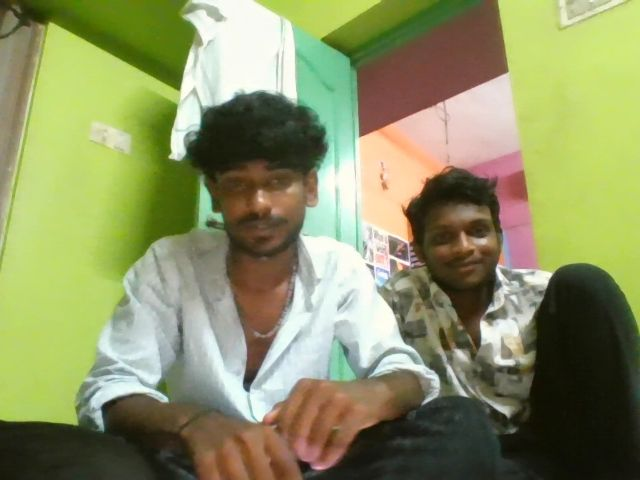

In [4]:
import cv2
from google.colab.patches import cv2_imshow

img = cv2.imread(photo)

cv2_imshow(img)